In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\Crude_Oil_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

         date       open       high        low      close  volume
0  2000-08-23  31.950001  32.799999  31.950001  32.049999   79385
1  2000-08-24  31.900000  32.240002  31.400000  31.629999   72978
2  2000-08-25  31.700001  32.099998  31.320000  32.049999   44601
3  2000-08-28  32.040001  32.919998  31.860001  32.869999   46770
4  2000-08-29  32.820000  33.029999  32.560001  32.720001   49131


In [4]:
# Chỉ lấy cột 'Close'
close_prices = df[['close']]

# Hiển thị 5 giá trị đầu tiên để kiểm tra
print(close_prices.head())

       close
0  32.049999
1  31.629999
2  32.049999
3  32.869999
4  32.720001


In [5]:
from sklearn.preprocessing import MinMaxScaler
# Khởi tạo scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Áp dụng scaler cho giá Close
scaled_close = scaler.fit_transform(close_prices)

print(scaled_close[:5])  # In ra 5 giá trị đầu tiên sau chuẩn hóa

[[0.38093157]
 [0.37863548]
 [0.38093157]
 [0.3854144 ]
 [0.38459438]]


In [6]:
# Tạo một bản sao của cột đã chuẩn hóa, gán tên là 'Close_scaler'
df['Close_scaler'] = scaled_close

# Tạo một Series từ cột 'Close_scaler' và đặt lại chỉ số
close_series = df['Close_scaler'].reset_index(drop=True)

# Kết quả là một Series 1D, chỉ số liên tục từ 0 đến N-1
print(close_series.head())
print(type(close_series))

0    0.380932
1    0.378635
2    0.380932
3    0.385414
4    0.384594
Name: Close_scaler, dtype: float64
<class 'pandas.core.series.Series'>


Chia chuỗi thời gian close_scaler thành 3 phần: 70% để train, 20% để validation, và 10% để test, đảm bảo đúng tỷ lệ và đúng thứ tự thời gian.

In [7]:
# Giả sử close_series đã được tạo như ở bước trước
total_len = len(close_series)

# Tính số phần tử cho mỗi phần
train_size = int(total_len * 0.7)
val_size = int(total_len * 0.2)
test_size = total_len - train_size - val_size  # Đảm bảo tổng đúng bằng total_len

# Chia theo thứ tự thời gian
train_data = close_series[:train_size]
val_data = close_series[train_size:train_size + val_size]
test_data = close_series[train_size + val_size:]

# In kiểm tra số lượng phần tử
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")


Train size: 4188
Validation size: 1196
Test size: 600


In [ ]:
# Đảm bảo y_test và y_pred đã reshape về dạng 2D: (n_samples, 1)
y_test_original = scalers['Brent_Crude_Oil'].inverse_transform(y_test_Crude_Oil.reshape(-1, 1))
y_pred_rnn_original = scalers['Brent_Crude_Oil'].inverse_transform(y_pred_rnn.reshape(-1, 1))
y_pred_lstm_original = scalers['Brent_Crude_Oil'].inverse_transform(y_pred_lstm.reshape(-1, 1))
y_pred_gru_original = scalers['Brent_Crude_Oil'].inverse_transform(y_pred_gru.reshape(-1, 1))


Tạo hàm create_dataset

In [8]:
import numpy as np

def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        x = dataset[i:(i + time_step)]    # time_step phần tử liên tiếp
        y = dataset[i + time_step]        # phần tử tiếp theo
        dataX.append(x)
        dataY.append(y)
    return np.array(dataX), np.array(dataY)

In [9]:
time_step = 10

# Chuyển Series thành numpy array và tạo cặp X, Y
X_train, y_train = create_dataset(train_data.to_numpy(), time_step)
X_val, y_val = create_dataset(val_data.to_numpy(), time_step)
X_test, y_test = create_dataset(test_data.to_numpy(), time_step)

# In kiểm tra shape
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4178, 10)
y_train shape: (4178,)
X_val shape: (1186, 10)
y_val shape: (1186,)
X_test shape: (590, 10)
y_test shape: (590,)


Chuyển đổi dữ liệu đầu vào X_train, X_val, X_test thành dạng 3 chiều [samples, time steps, features] để phù hợp với yêu cầu của các mô hình RNN.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

In [12]:
# Xây dựng mô hình RNN
modelRNN = Sequential()
modelRNN.add(SimpleRNN(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
modelRNN.add(Dense(1))  # Lớp đầu ra dự đoán một giá trị liên tục

# Compile mô hình
modelRNN.compile(optimizer='adam', loss='mean_squared_error')

d:\Python_3_10\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# Huấn luyện mô hình
history = modelRNN.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0295 - val_loss: 5.1576e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.9293e-04 - val_loss: 3.6723e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.8171e-04 - val_loss: 3.0547e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6975e-04 - val_loss: 2.3318e-04
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.5353e-04 - val_loss: 3.5699e-04
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5628e-04 - val_loss: 4.1648e-04
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5608e-04 - val_loss: 2.0292e-04
Epoch 8/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4142e-04 - val_loss: 3.4394e-04
Epoch 9/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1151e-04 - val_loss: 1.8722e-04
Epoch 10/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1523e-04 - val_loss: 2.3453e-04
Epoch 11/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [15]:
# Khởi tạo mô hình tuần tự
modelLSTM = Sequential()

# Thêm lớp LSTM với 50 đơn vị ẩn
modelLSTM.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))

# Lớp đầu ra (một giá trị liên tục)
modelLSTM.add(Dense(1))

# Compile mô hình
modelLSTM.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
history_lstm = modelLSTM.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0352 - val_loss: 3.0226e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.2072e-04 - val_loss: 2.7144e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.2334e-04 - val_loss: 2.8676e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.1675e-04 - val_loss: 2.6852e-04
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.0686e-04 - val_loss: 2.8856e-04
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.1332e-04 - val_loss: 2.5361e-04
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.9869e-04 - val_loss: 2.5825e-04
Epoch 8/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9407e-04 - val_loss: 3.7124e-04
Epoch 9/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2489e-04 - val_loss: 4.7747e-04
Epoch 10/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.7333e-04 - val_loss: 3.7174e-04
Epoch 11/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

In [18]:
# Khởi tạo mô hình
modelGRU = Sequential()

# Thêm lớp GRU với 50 đơn vị
modelGRU.add(GRU(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))

# Lớp đầu ra
modelGRU.add(Dense(1))

# Compile mô hình
modelGRU.compile(optimizer='adam', loss='mean_squared_error')

In [19]:
history_gru = modelGRU.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0446 - val_loss: 2.2705e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.4584e-04 - val_loss: 2.0896e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.5226e-04 - val_loss: 2.0124e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.3427e-04 - val_loss: 2.0729e-04
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1441e-04 - val_loss: 1.8687e-04
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.1333e-04 - val_loss: 1.8257e-04
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0995e-04 - val_loss: 2.2799e-04
Epoch 8/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.4118e-04 - val_loss: 2.0382e-04
Epoch 9/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0558e-04 - val_loss: 1.7978e-04
Epoch 10/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1293e-04 - val_loss: 1.7210e-04
Epoch 11/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/ste

Tính RMSE (Root Mean Squared Error) của các mô hình RNN, LSTM và GRU trên tập test y_test và in kết quả ra màn hình.

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [21]:
# Dự đoán
y_pred_rnn = modelRNN.predict(X_test)
y_pred_lstm = modelLSTM.predict(X_test)
y_pred_gru = modelGRU.predict(X_test)

# Tính RMSE
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [22]:
print(f"RMSE RNN  : {rmse_rnn:.4f}")
print(f"RMSE LSTM : {rmse_lstm:.4f}")
print(f"RMSE GRU  : {rmse_gru:.4f}")

RMSE RNN  : 0.0129
RMSE LSTM : 0.0135
RMSE GRU  : 0.0128


In [23]:
# Chuyển y_test sang 2D array nếu cần (y_test thường là 1D)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_rnn_original = scaler.inverse_transform(y_pred_rnn)
y_pred_lstm_original = scaler.inverse_transform(y_pred_lstm)
y_pred_gru_original = scaler.inverse_transform(y_pred_gru)

In [24]:
print("Giá Close thực tế (y_test):", y_test_original[:5].flatten())
print("Dự đoán RNN:", y_pred_rnn_original[:5].flatten())
print("Dự đoán LSTM:", y_pred_lstm_original[:5].flatten())
print("Dự đoán GRU:", y_pred_gru_original[:5].flatten())

Giá Close thực tế (y_test): [91.76000214 91.06999969 92.34999847 92.09999847 92.80999756]
Dự đoán RNN: [94.4299  92.51072 91.53488 93.07954 92.48088]
Dự đoán LSTM: [94.66468  92.74966  92.089935 93.261795 93.040825]
Dự đoán GRU: [93.120575 91.15843  90.439156 91.74476  91.419655]


In [25]:
import matplotlib.pyplot as plt

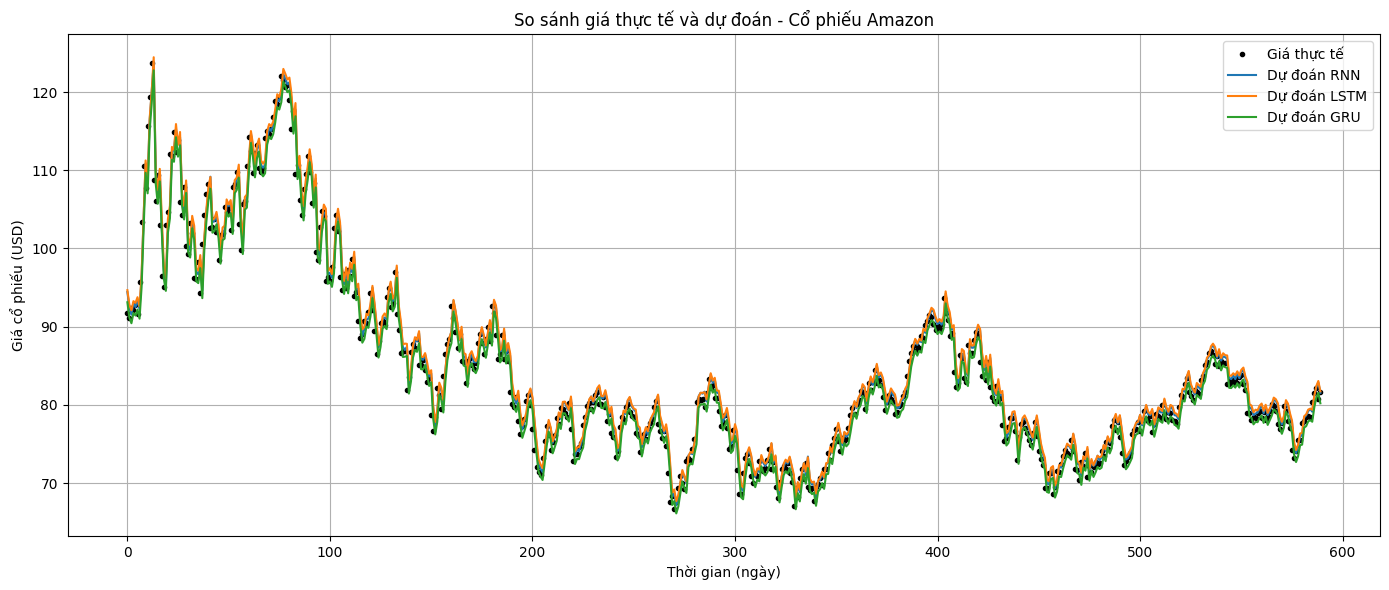

In [26]:
plt.figure(figsize=(14, 6))

# Giá thực tế: vẽ dạng scatter (dạng chấm tròn)
plt.plot(y_test_original, 'o', label='Giá thực tế', markersize=3, color='black')

# Các dự đoán: vẽ dạng đường
plt.plot(y_pred_rnn_original, label='Dự đoán RNN', linestyle='-')
plt.plot(y_pred_lstm_original, label='Dự đoán LSTM', linestyle='-')
plt.plot(y_pred_gru_original, label='Dự đoán GRU', linestyle='-')

# Tùy chỉnh biểu đồ
plt.title('So sánh giá thực tế và dự đoán - Cổ phiếu Amazon')
plt.xlabel('Thời gian (ngày)')
plt.ylabel('Giá cổ phiếu (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Viết hàm predict_future để dự đoán n_days tiếp theo từ chuỗi đầu vào cuối cùng, sử dụng mô hình đã huấn luyện (GRU, RNN, LSTM...), sau đó chuyển kết quả từ dạng chuẩn hóa về giá trị gốc bằng scaler.

In [27]:
def predict_future(model, last_sequence, n_days, scaler):
    predictions = []
    input_seq = last_sequence.copy()  # giữ nguyên input gốc

    for _ in range(n_days):
        # Reshape về (1, time_steps, 1) để dự đoán
        pred = model.predict(input_seq.reshape(1, -1, 1), verbose=0)

        # Thêm vào danh sách dự đoán
        predictions.append(pred[0, 0])

        # Cập nhật chuỗi đầu vào: bỏ giá trị đầu, thêm giá trị dự đoán
        input_seq = np.append(input_seq[1:], [[pred[0, 0]]], axis=0)

    # Chuyển từ [0,1] về giá trị gốc
    predictions = np.array(predictions).reshape(-1, 1)
    predictions_original = scaler.inverse_transform(predictions)

    return predictions_original.flatten()

In [28]:
# Giả sử bạn dùng sequence length = 60 để tạo X_test trước đó
sequence_length = X_test.shape[1]

# Lấy chuỗi dữ liệu cuối cùng từ test_data
last_sequence = test_data[-sequence_length:]  # shape: (60, 1)
# Đảm bảo last_sequence là mảng numpy
last_sequence = np.array(last_sequence)

# Kiểm tra shape để đảm bảo nó có dạng (60, 1) trước khi dự đoán
last_sequence = last_sequence.reshape(-1, 1)

In [29]:
# Dự đoán 10 ngày tiếp theo với mỗi mô hình
future_rnn = predict_future(modelRNN, last_sequence, n_days=10, scaler=scaler)
future_lstm = predict_future(modelLSTM, last_sequence, n_days=10, scaler=scaler)
future_gru = predict_future(modelGRU, last_sequence, n_days=10, scaler=scaler)

In [30]:
print("Dự đoán 10 ngày tiếp theo bằng mô hình RNN:")
print(future_rnn)

print("\nDự đoán 10 ngày tiếp theo bằng mô hình LSTM:")
print(future_lstm)

print("\nDự đoán 10 ngày tiếp theo bằng mô hình GRU:")
print(future_gru)

Dự đoán 10 ngày tiếp theo bằng mô hình RNN:
[82.328384 83.02435  83.59898  84.33959  84.97522  85.67169  86.35414
 87.068214 87.747826 88.435104]

Dự đoán 10 ngày tiếp theo bằng mô hình LSTM:
[82.53247  83.38305  84.25023  85.13175  86.02022  86.91257  87.806465
 88.70161  89.59838  90.49907 ]

Dự đoán 10 ngày tiếp theo bằng mô hình GRU:
[81.02647  80.41866  79.820755 79.25967  78.66081  78.07064  77.485466
 76.897255 76.31039  75.72404 ]


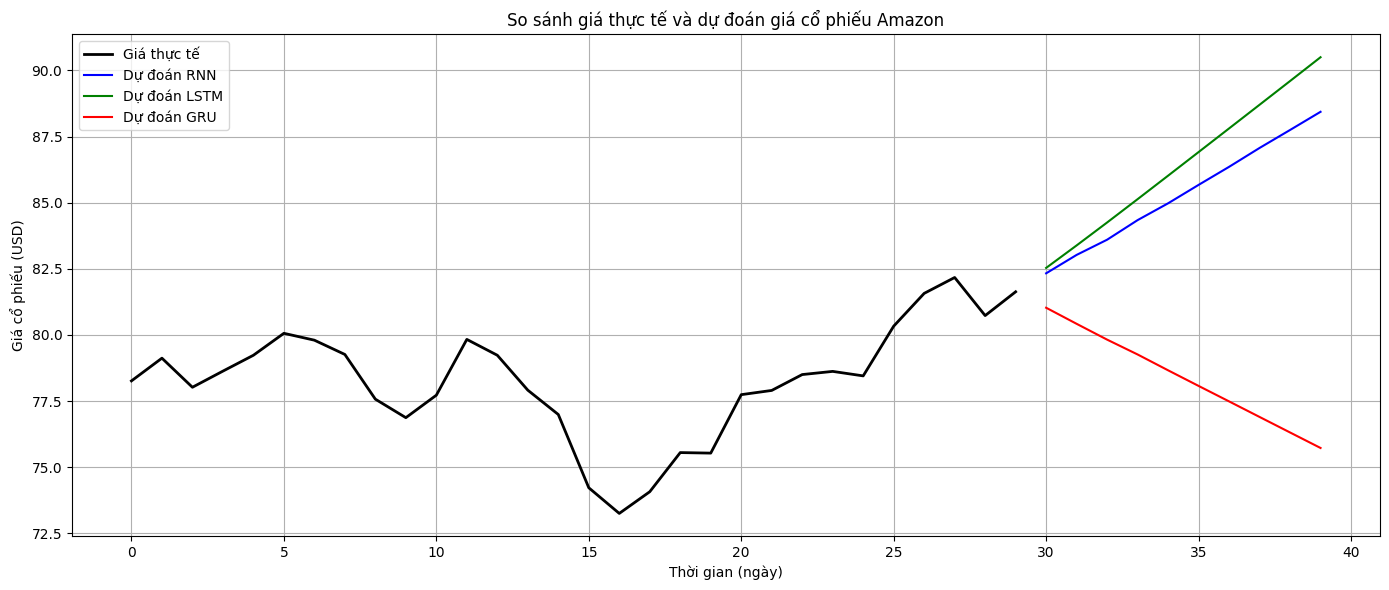

In [31]:
import matplotlib.pyplot as plt

# Xác định time_step và lấy giá trị thực tế trong 30 bước cuối cùng
time_step = 30
real_prices = y_test_original[-time_step:]  # Lấy 30 bước cuối từ y_test

# Dự đoán 10 ngày tiếp theo cho mỗi mô hình
future_rnn = predict_future(modelRNN, last_sequence, n_days=10, scaler=scaler)
future_lstm = predict_future(modelLSTM, last_sequence, n_days=10, scaler=scaler)
future_gru = predict_future(modelGRU, last_sequence, n_days=10, scaler=scaler)

# Tạo biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ giá thực tế (30 bước cuối cùng dưới dạng đường thẳng)
plt.plot(range(time_step), real_prices, label='Giá thực tế', color='black', linewidth=2)

# Vẽ các dự đoán của các mô hình (RNN, LSTM, GRU) dưới dạng đường thẳng
plt.plot(range(time_step, time_step + 10), future_rnn, label='Dự đoán RNN', linestyle='-', color='blue')
plt.plot(range(time_step, time_step + 10), future_lstm, label='Dự đoán LSTM', linestyle='-', color='green')
plt.plot(range(time_step, time_step + 10), future_gru, label='Dự đoán GRU', linestyle='-', color='red')

# Tùy chỉnh biểu đồ
plt.title('So sánh giá thực tế và dự đoán giá cổ phiếu Amazon')
plt.xlabel('Thời gian (ngày)')
plt.ylabel('Giá cổ phiếu (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()